# General plume transmittance model fit demonstration

Part demonstration, part prototype, the following demonstrates and
validates curve-fitting operations and metrics generation based on the
model of generalized plume transmittance (eq. 6 from Xiang, et al.):

$ f(\lambda,\left(\boldsymbol\theta,\alpha\right)) = \left(\sum\limits_{i=0}^{N}\theta_{i}\lambda^{i}\right) e^{-\epsilon(\lambda)\alpha} $

Note that this demo is based on output from demo_plume_pairing.ipynb,
specifically, target and background radiances for a randomly-chosen
test plume, so that notebook will need to be run first. Also, note
that, for test purposes, scene absorptivity is a sample of
randomly-chosen AVIRIS data, perhaps later to be replaced by a
restructured call to ghg_process().

In addition to step-by-step diagnostic plots, "output" for the plume
is a normalized "goodness of fit" (eq. 11 from Xiang, et al.) and
transmittance model concentration length, multiplied by 1.e5, by
convention.

In [37]:

#
# Test/demonstrate plume transmittance model curve fitting, based on
# demo_plume_pixel_pairing.ipynb results
#

import functools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import yaml

import pv


# data:
cfg_src = './config.yaml'
plume_data_src = './data/previous_manual_annotation_oneback.json'
cfg = yaml.safe_load(open(cfg_src))

# plume instance (also provides access to ch4 matched filter results):
plume = pv.emit_plume.EMITPlume(
    plume_id='CH4_PlumeComplex-3727',
    plume_data=plume_data_src,
    cfg=cfg)

# radiance data:
l1b_radiance = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l1b',
    type=cfg['emit_l1b_radiance_type'],
    ext='hdr')
wl = np.array(l1b_radiance.hdr['wavelength'],dtype=float)

# nominal target methane absorptivity data (note: these data bear no relation to
# the current plume, and are only being used here for test purposes in place of
# an actual call to ghg_process):
ch4_eps = pd.read_csv('./data/AV320241104t181131_target.csv',sep='\\s+',names=['index','lambda','eps'],header=None)
ch4_eps['eps'] *= -1.
# since these values have been provided on a slightly different wavelength grid,
# interpolate to EMIT spectra:
ch4_eps_interp = np.interp(wl,ch4_eps['lambda'],ch4_eps['eps'])

In [38]:
# retrieve paired target and background pixel radiances output from
# demo_plume_pairing.ipynb:
with open('demo_plume_pixel_pairing_target_radiances.npy','rb') as f:
    target_radiances = np.load(f)
with open('demo_plume_pixel_pairing_background_radiances.npy','rb') as f:
    background_radiances = np.load(f)

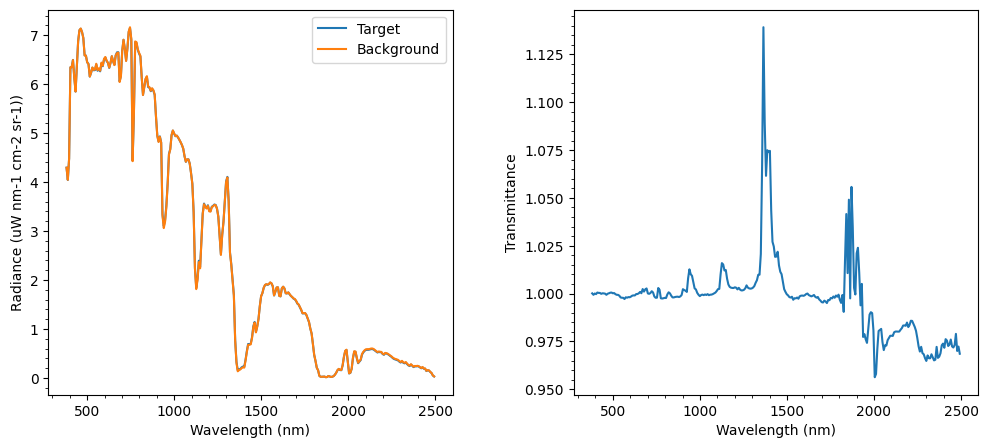

In [39]:
# Take a look at target and background radiances, and their ratio, which will be
# the subject of the transmittance model fit exercise:  
fig, axs = plt.subplots(1,2,figsize=(12,5))
axs[0].plot(wl,np.mean(target_radiances,axis=0),label='Target')
axs[0].plot(wl,np.mean(background_radiances,axis=0),label='Background')
axs[0].minorticks_on()
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Radiance (uW nm-1 cm-2 sr-1))')
axs[0].legend()
axs[0].minorticks_on()
target_background_radiance_ratio = \
    np.mean(target_radiances,axis=0)/np.mean(background_radiances,axis=0)
axs[1].plot(wl,target_background_radiance_ratio)
axs[1].minorticks_on()
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel('Transmittance')
plt.subplots_adjust(wspace=0.3,hspace=0.3)

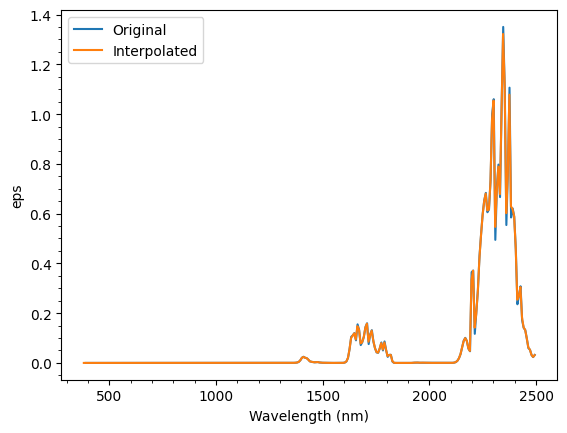

In [40]:
# Test target absorptivities are wavelenth-discretized on a slightly
# different grid than EMIT; interpolate, and plot, just to verify:
fig, axs = plt.subplots()
# original:
axs.plot(ch4_eps['lambda'],ch4_eps['eps'],label='Original')
# interpolated:
ch4_eps
axs.plot(wl,ch4_eps_interp,label='Interpolated')
axs.minorticks_on()
axs.set_xlabel('Wavelength (nm)')
axs.set_ylabel('eps')
axs.legend()

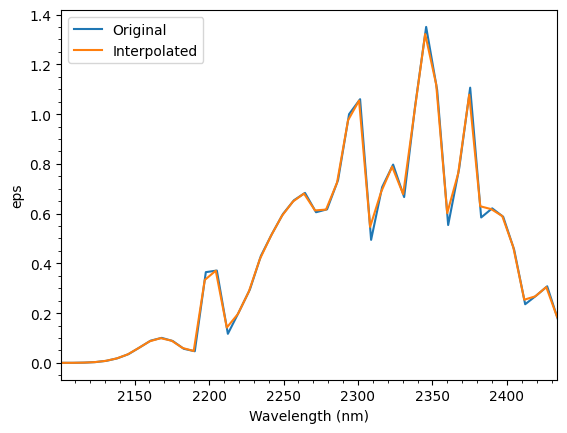

In [41]:
# same plot as above, but limited to ch4 model fitting range:
# ch4 wavelength indices for model fitting:
ch4_fitting_rngs = np.array(cfg['ch4_fitting_absorption_ranges'])
ch4_fitting_wl_indices = []
for i in range(ch4_fitting_rngs.shape[0]):
    ch4_fitting_wl_indices.extend(list(np.where((wl >= ch4_fitting_rngs[i,0]) & (wl <= ch4_fitting_rngs[i,1]))[0]))
# and, just to be sure, make sure none of the indices are repeated, and 
# sort for convenience:
ch4_fitting_wl_indices = list(set(ch4_fitting_wl_indices))
ch4_fitting_wl_indices.sort()
fig, axs = plt.subplots()
# original:
axs.plot(ch4_eps['lambda'],ch4_eps['eps'],label='Original')
# interpolated:
axs.plot(wl,ch4_eps_interp,label='Interpolated')
axs.set_xlim(wl[ch4_fitting_wl_indices[0]],wl[ch4_fitting_wl_indices[-1]])
axs.minorticks_on()
axs.set_xlabel('Wavelength (nm)')
axs.set_ylabel('eps')
axs.legend()

In [42]:
transmittance_model_fixed_epsilon = functools.partial(
    pv.utils.transmittance_model,epsilon=ch4_eps_interp[ch4_fitting_wl_indices])

In [43]:
popt, _ = curve_fit(
    transmittance_model_fixed_epsilon,
    wl[ch4_fitting_wl_indices],
    target_background_radiance_ratio[ch4_fitting_wl_indices],
    # p0 = [1.,0.,0.,0.,0.,0.,0.,0.]
    p0 = [1.] + [0.]*(cfg['TRANSMITTANCE_MODEL_POLYNOMIAL_DEGREE']+1))

In [44]:
print(popt)

[ 7.20812747e-03 -2.24678716e-31  7.53738584e-28  1.72274144e-24
 -4.41453427e-21 -6.10007911e-18 -1.72821335e-14  1.35072190e-12
  3.18938773e-07 -7.39076853e-05 -1.39704829e+00  1.42934032e+03]


In [45]:
print(*popt)

0.007208127465278372 -2.2467871568179748e-31 7.537385842392399e-28 1.722741440859031e-24 -4.414534274837583e-21 -6.100079106946229e-18 -1.7282133477758607e-14 1.3507218961078622e-12 3.189387726131034e-07 -7.390768525937454e-05 -1.3970482867265932 1429.3403203438193


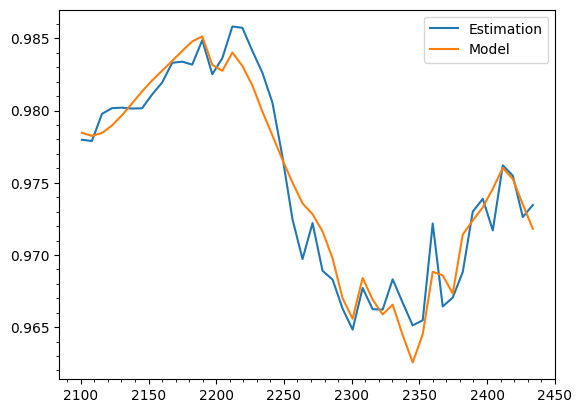

In [46]:
fig, axs = plt.subplots()
axs.plot(
    wl[ch4_fitting_wl_indices],
    target_background_radiance_ratio[ch4_fitting_wl_indices],
    label='Estimation')
axs.plot(
    wl[ch4_fitting_wl_indices],
    pv.utils.transmittance_model(
        wl[ch4_fitting_wl_indices],
        *popt,
        epsilon=ch4_eps_interp[ch4_fitting_wl_indices]),
    label='Model')
axs.minorticks_on()
axs.legend()

In [47]:
# "goodnes" of fit metrics:
# what follows is "as implemented" in the original plume vetting code, using the 
# options as described in Chuchu et al. Much could be done to improve the 
# approach, beginning with questioning its rationale.

In [48]:
(transmittance_model_polynomial, transmittance_model_exponential) = pv.utils.transmittance_model_components(
    wl[ch4_fitting_wl_indices],
    *popt,
    epsilon=ch4_eps_interp[ch4_fitting_wl_indices])

# estimated target/background radiance ratio, "normalized" by transmittance_model_polynomial:
normalized_target_background_radiance_ratio = \
    target_background_radiance_ratio[ch4_fitting_wl_indices]/transmittance_model_polynomial

# modeled target/background radiance ratio, "normalized" by
# transmittance_model_polynomial (which, by definition, leaves just the 
# exponential portion of the fit):
normalized_modeled_target_background_radiance_ratio = transmittance_model_exponential


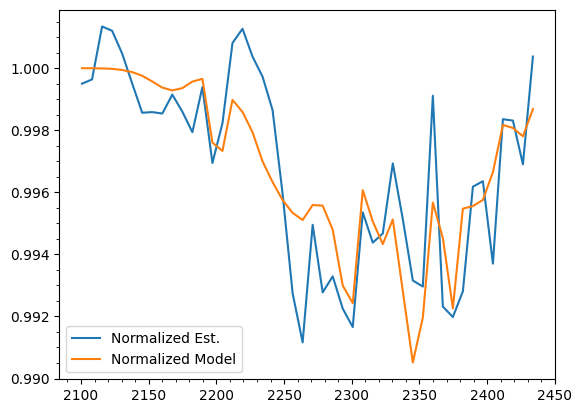

In [49]:
fig, axs = plt.subplots()
axs.plot(wl[ch4_fitting_wl_indices],normalized_target_background_radiance_ratio,label='Normalized Est.')
axs.plot(wl[ch4_fitting_wl_indices],normalized_modeled_target_background_radiance_ratio,label='Normalized Model')
axs.minorticks_on()
axs.legend()

In [50]:
dist = np.mean(np.abs(
    normalized_target_background_radiance_ratio - 
    normalized_modeled_target_background_radiance_ratio))

In [51]:
mag = np.mean(np.abs(normalized_target_background_radiance_ratio - np.mean(normalized_target_background_radiance_ratio)))

In [52]:
normalized_dist = dist/mag

In [53]:
print(f'D_norm: {normalized_dist}, model concentration length (*1e5): {popt[0]*1.e5}')

D_norm: 0.5017253636721201, model concentration length (*1e5): 720.8127465278372
